In [1]:
%pip install --upgrade terndata.ecoplots


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# EcoPlots Python Library - Use case 1 - Animal occurrence in North Queensland

This example showcases how to get the occurrences of animal species in North Queensland from the Williams Wet 
Tropics dataset (244k occurrences).

We get the most common recorded specie and we plot them in a map.

In [1]:
from terndata.ecoplots import EcoPlots
ecoplots = EcoPlots()

# Display the client information
print(ecoplots)

EcoPlots initialized in observations mode.
╔══════════════════════════════════════════════════════════════════════════════╗
║ EcoPlots Observations                                                        ║
║ Version: 1.1.2                                                               ║
╠══════════════════════════════════════════════════════════════════════════════╣
║ No filters applied                                                           ║
╚══════════════════════════════════════════════════════════════════════════════╝


In [7]:

# Select animal occurrence data for the observed property "taxon"
ecoplots.select(feature_type="animal occurrence").select(observed_property="scientific name")
# List available data sources
ecoplots.get_datasources()

,key,uri
0,Williams Wet Tropics Vertebrate database,http://linked.data.gov.au/dataset/wet-tropics-...


In [8]:
# Summarise the data before downloading it into a DataFrame
ecoplots.summarise_data()

{'total_doc': 244064,
 'unique_count': {'dataset': 1,
  'feature_type': 1,
  'observed_property': 1,
  'site': 0,
  'site_visit': 0}}

In [5]:
# Download the data into a DataFrame. By default, this will return a pandas DataFrame.
# The total ammount of data downloaded will be 244k rows. This may take a few moments.
df_animal = ecoplots.get_data()

In [9]:
# Display the first few rows of the DataFrame
df_animal.head()

,datasetTitle,latitude_Degree,longitude_Degree,featureType,featureId,scientificName,scientificNameResultTime,scientificNameMethod,geometry
0,Williams Wet Tropics Vertebrate database,-17.409718,145.980820,animal occurrence,http://linked.data.gov.au/dataset/wet-tropics-...,Casuarius casuarius,2001-05-01T00:00:00,http://linked.data.gov.au/def/tern-cv/de94b8fd...,POINT (145.98082 -17.40972)
1,Williams Wet Tropics Vertebrate database,-16.069324,145.462097,animal occurrence,http://linked.data.gov.au/dataset/wet-tropics-...,Casuarius casuarius,2007-01-19T00:00:00,http://linked.data.gov.au/def/tern-cv/de94b8fd...,POINT (145.4621 -16.06932)
2,Williams Wet Tropics Vertebrate database,-17.515404,145.512604,animal occurrence,http://linked.data.gov.au/dataset/wet-tropics-...,Casuarius casuarius,1996-06-01T00:00:00,http://linked.data.gov.au/def/tern-cv/de94b8fd...,POINT (145.5126 -17.5154)
3,Williams Wet Tropics Vertebrate database,-17.855900,146.060898,animal occurrence,http://linked.data.gov.au/dataset/wet-tropics-...,Casuarius casuarius,1997-07-21T00:00:00,http://linked.data.gov.au/def/tern-cv/de94b8fd...,POINT (146.0609 -17.8559)
4,Williams Wet Tropics Vertebrate database,-17.254171,145.637497,animal occurrence,http://linked.data.gov.au/dataset/wet-tropics-...,Podiceps cristatus australis,1993-07-01T00:00:00,http://linked.data.gov.au/def/tern-cv/de94b8fd...,POINT (145.6375 -17.25417)


In [6]:
# Count occurrences of each scientific name, sorted in descending order (most frequent first)
df_animal['scientificName'].groupby(df_animal['scientificName']).count().sort_values(ascending=False)

scientificName
Cophixalus ornatus                     9844
Gerygone mouki mouki                   7491
Heteromyias cinereifrons               6666
Sericornis (Arfakornis) magnirostra    5810
Carlia rubrigularis                    5708
                                       ... 
Lampropholis adonis                       1
Lampropholis amicula                      1
Pygopus schraderi                         1
Ptilotula plumula planasi                 1
APODIDAE                                  1
Name: scientificName, Length: 587, dtype: int64

In [12]:
# Install required packages for plotting the data
%pip install matplotlib cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 2.8 MB/s  0:00:03 eta 0:00:01m

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


<Axes: xlabel='longitude_Degree', ylabel='latitude_Degree'>

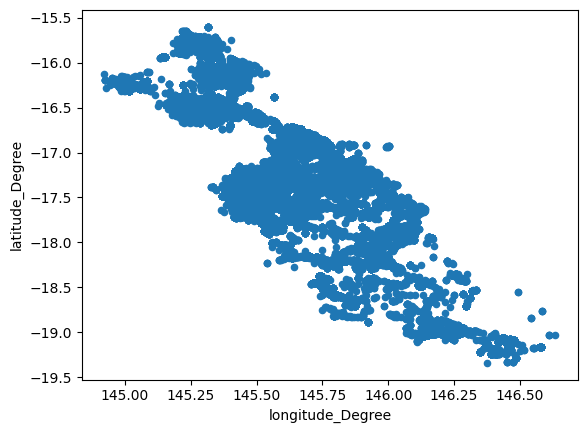

In [7]:
df_animal.plot(x="longitude_Degree", y="latitude_Degree", kind="scatter")

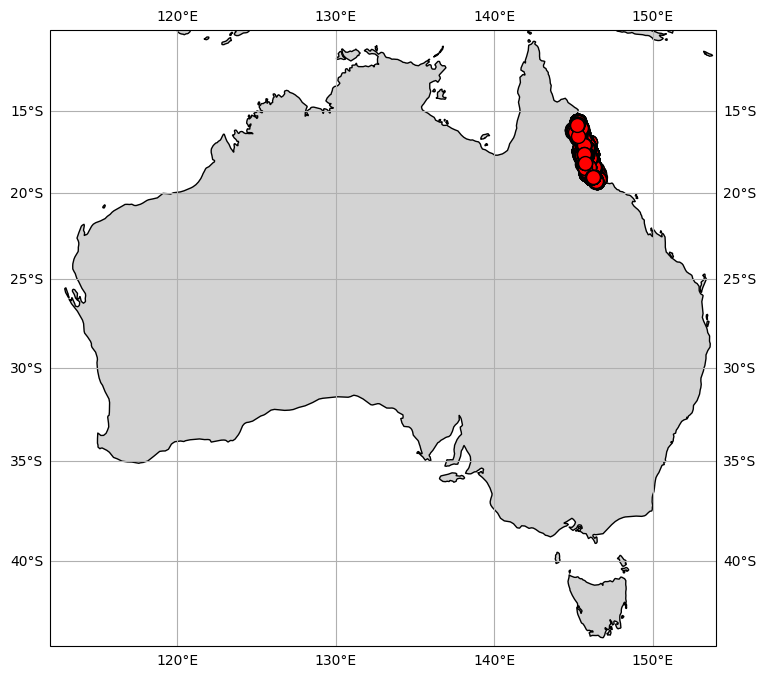

In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Create a figure and set up an axes with a Mercator projection
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.Mercator())

# 2. Set the bounding box for Australia [min_lon, max_lon, min_lat, max_lat]
# We tell Cartopy these numbers are standard Geodetic (lat/lon) coordinates
ax.set_extent([112, 154, -44, -10], crs=ccrs.PlateCarree())

# 3. Add map features (equivalent to Basemap's resolution='i')
ax.add_feature(cfeature.COASTLINE.with_scale('50m'))  # Intermediate resolution
ax.add_feature(cfeature.BORDERS.with_scale('50m'))    # Country borders
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray')

# Optional: Add gridlines with labels
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# 4. Draw your points onto the map
# CRITICAL: transform=ccrs.PlateCarree() translates raw lat/lon to the map's projection
ax.scatter(
    df_animal['longitude_Degree'].values, 
    df_animal['latitude_Degree'].values, 
    color='red', 
    marker='o', 
    s=100,                  # Size of the points
    edgecolor='black',      # Border around points
    zorder=5,               # Ensures points stay on top of the map layer
    transform=ccrs.PlateCarree() 
)

plt.show()

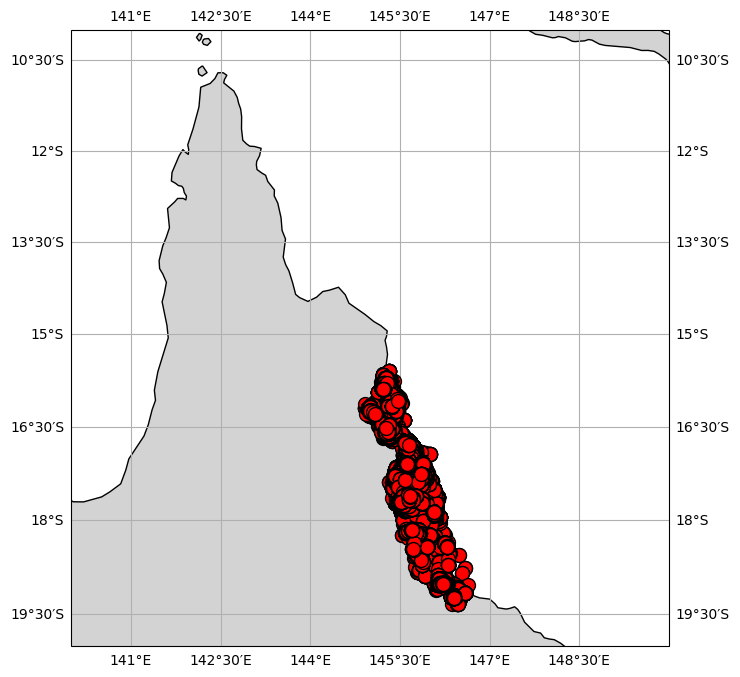

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Create a figure and set up an axes with a Mercator projection
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.Mercator())

# 2. Set the bounding box for Australia [min_lon, max_lon, min_lat, max_lat]
# We tell Cartopy these numbers are standard Geodetic (lat/lon) coordinates

ax.set_extent([140, 150, -20, -10], crs=ccrs.PlateCarree())

# 3. Add map features (equivalent to Basemap's resolution='i')
ax.add_feature(cfeature.COASTLINE.with_scale('50m'))  # Intermediate resolution
ax.add_feature(cfeature.BORDERS.with_scale('50m'))    # Country borders
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray')

# Optional: Add gridlines with labels
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# 4. Draw your points onto the map
# CRITICAL: transform=ccrs.PlateCarree() translates raw lat/lon to the map's projection
ax.scatter(
    df_animal['longitude_Degree'].values, 
    df_animal['latitude_Degree'].values, 
    color='red', 
    marker='o', 
    s=100,                  # Size of the points
    edgecolor='black',      # Border around points
    zorder=5,               # Ensures points stay on top of the map layer
    transform=ccrs.PlateCarree() 
)

plt.show()

In [10]:
species_abundance = (
    df_animal["scientificName"]
    .value_counts()
    .rename_axis("scientificName")
    .reset_index(name="abundance")
)

species_abundance

,scientificName,abundance
0,Cophixalus ornatus,9844
1,Gerygone mouki mouki,7491
2,Heteromyias cinereifrons,6666
3,Sericornis (Arfakornis) magnirostra,5810
4,Carlia rubrigularis,5708
...,...,...
582,Varanus tristis orientalis,1
583,Glaphyromorphus crassicaudus,1
584,Lampropholis adonis,1
585,Acanthagenys rufogularis,1


In [11]:
species_abundance["relative_abundance"] = (
    species_abundance["abundance"] / species_abundance["abundance"].sum()
)

species_abundance

,scientificName,abundance,relative_abundance
0,Cophixalus ornatus,9844,0.040334
1,Gerygone mouki mouki,7491,0.030693
2,Heteromyias cinereifrons,6666,0.027313
3,Sericornis (Arfakornis) magnirostra,5810,0.023805
4,Carlia rubrigularis,5708,0.023387
...,...,...,...
582,Varanus tristis orientalis,1,0.000004
583,Glaphyromorphus crassicaudus,1,0.000004
584,Lampropholis adonis,1,0.000004
585,Acanthagenys rufogularis,1,0.000004


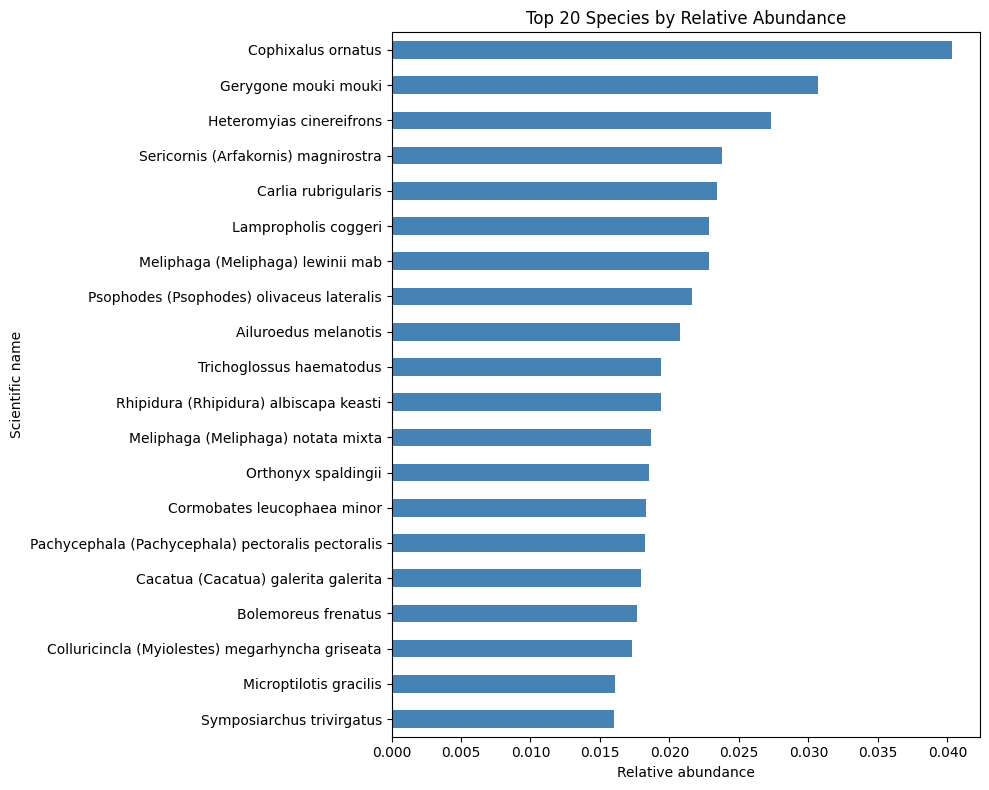

In [12]:
top_species = species_abundance.head(20).sort_values("relative_abundance")

ax = top_species.plot(
    x="scientificName",
    y="relative_abundance",
    kind="barh",
    figsize=(10, 8),
    legend=False,
    color="steelblue",
)

ax.set_title("Top 20 Species by Relative Abundance")
ax.set_xlabel("Relative abundance")
ax.set_ylabel("Scientific name")
plt.tight_layout()
plt.show()

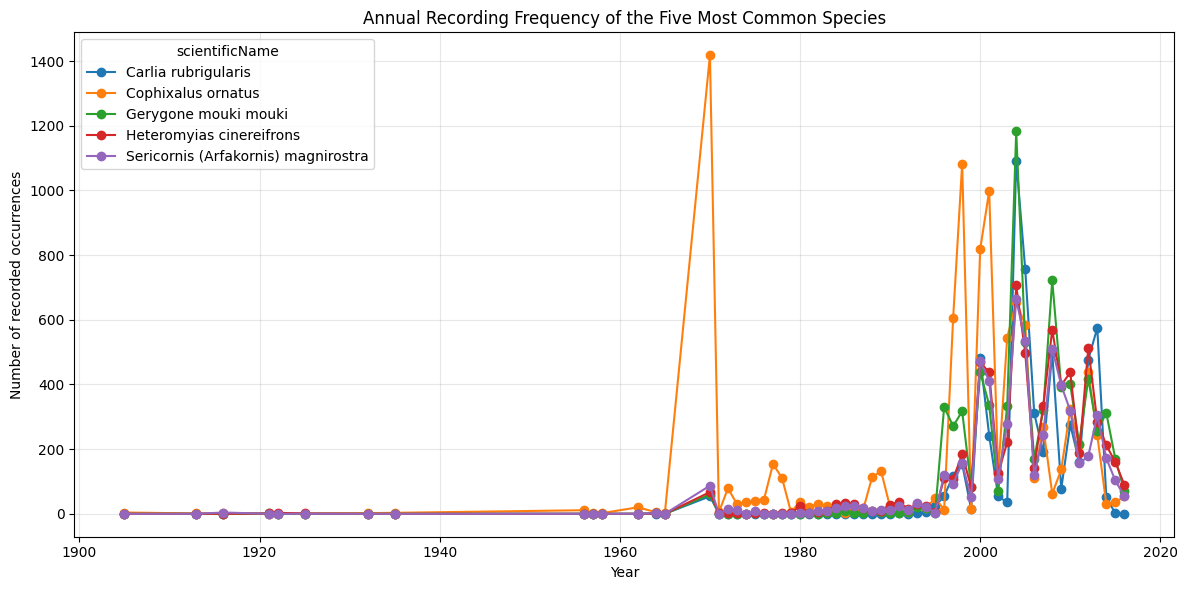

In [14]:
top5_names = species_abundance.head(5)["scientificName"]

yearly_occurrences = (
    df_animal.assign(
        year=df_animal["scientificNameResultTime"].str[:4].astype("Int64")
    )
    .loc[lambda data: data["scientificName"].isin(top5_names)]
    .groupby(["year", "scientificName"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

ax = yearly_occurrences.plot(figsize=(12, 6), marker="o")

ax.set_title("Annual Recording Frequency of the Five Most Common Species")
ax.set_xlabel("Year")
ax.set_ylabel("Number of recorded occurrences")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()